In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)

In [4]:

CSV_PATH = r"/content/DT_Placement.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df)

Dataset loaded successfully.
Shape: (14, 6)


,ID,CGPA,Internships,Backlogs,Aptitude,Placed
0,S1,8.6,2,No,73,Yes
1,S2,9.4,2,No,76,Yes
2,S3,9.0,2,No,81,Yes
3,S4,5.2,0,Yes,48,No
4,S5,5.3,0,Yes,44,No
5,S6,5.0,1,No,83,No
6,S7,6.2,1,Yes,63,No
7,S8,6.2,0,Yes,52,Yes
8,S9,8.7,2,Yes,77,Yes
9,S10,7.5,1,No,70,Yes


In [10]:
# ============================================================
# 4. DATA PREPROCESSING
# ============================================================
# Create a copy so that the original dataset remains unchanged.
data_model = df.copy()

# ID is only an identifier and should not be used for training.
data_model = data_model.drop(columns=["ID"])

# Convert Yes/No values to 1/0.
mapping = {"no": 0, "yes": 1}
for col in ["Backlogs", "Placed"]:
    data_model[col] = data_model[col].astype(str).str.strip().str.lower().map(mapping)

# Check the result.
print("Preprocessed dataset:")
display(data_model)

print("\nData types:")
print(data_model.dtypes)

Preprocessed dataset:


,CGPA,Internships,Backlogs,Aptitude,Placed
0,8.6,2,0,73,1
1,9.4,2,0,76,1
2,9.0,2,0,81,1
3,5.2,0,1,48,0
4,5.3,0,1,44,0
5,5.0,1,0,83,0
6,6.2,1,1,63,0
7,6.2,0,1,52,1
8,8.7,2,1,77,1
9,7.5,1,0,70,1



Data types:
CGPA           float64
Internships      int64
Backlogs         int64
Aptitude         int64
Placed           int64
dtype: object


In [11]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=data_model)



https://docs.google.com/spreadsheets/d/1B83pdfgTN195CJ-oeYiLHVr5lvMaCsnK51k2pU6BJsc/edit#gid=0


In [12]:
# ============================================================
# 5. DEFINE X AND y
# ============================================================

X = data_model.drop(columns=["Placed"])
y = data_model["Placed"]

print("Features:", X.columns.tolist())
print("Target: Placed")

Features: ['CGPA', 'Internships', 'Backlogs', 'Aptitude']
Target: Placed


In [13]:
X

,CGPA,Internships,Backlogs,Aptitude
0,8.6,2,0,73
1,9.4,2,0,76
2,9.0,2,0,81
3,5.2,0,1,48
4,5.3,0,1,44
5,5.0,1,0,83
6,6.2,1,1,63
7,6.2,0,1,52
8,8.7,2,1,77
9,7.5,1,0,70


In [15]:
# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())


Training samples: 9
Validation samples: 5

Training class distribution:
Placed
1    5
0    4
Name: count, dtype: int64

Validation class distribution:
Placed
1    3
0    2
Name: count, dtype: int64


In [16]:
# ============================================================
# 7. SINGLE DECISION TREE BASELINE
# ============================================================

dt_baseline = DecisionTreeClassifier(
        criterion="entropy",
    random_state=42
)

dt_baseline.fit(X_train, y_train)

dt_train_pred = dt_baseline.predict(X_train)
dt_val_pred = dt_baseline.predict(X_val)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_val_acc = accuracy_score(y_val, dt_val_pred)

print("SINGLE DECISION TREE")
print("=" * 50)
print(f"Training Accuracy   : {dt_train_acc:.4f}")
print(f"Validation Accuracy : {dt_val_acc:.4f}")
print(f"Tree Depth          : {dt_baseline.get_depth()}")
print(f"Number of Leaves    : {dt_baseline.get_n_leaves()}")



SINGLE DECISION TREE
Training Accuracy   : 1.0000
Validation Accuracy : 0.6000
Tree Depth          : 3
Number of Leaves    : 4


In [17]:
# ============================================================
# 8. TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)

print("RANDOM FOREST")
print("=" * 50)
print(f"Number of Trees     : {rf.n_estimators}")
print(f"Training Accuracy   : {rf_train_acc:.4f}")
print(f"Validation Accuracy : {rf_val_acc:.4f}")
print(f"OOB Accuracy        : {rf.oob_score_:.4f}")
print(f"OOB Error           : {1 - rf.oob_score_:.4f}")


RANDOM FOREST
Number of Trees     : 100
Training Accuracy   : 1.0000
Validation Accuracy : 0.8000
OOB Accuracy        : 0.5556
OOB Error           : 0.4444


In [18]:
len(rf.estimators_)


100

In [19]:
print(rf.estimators_[0])


DecisionTreeClassifier(criterion='entropy', max_features='sqrt',
                       random_state=1608637542)


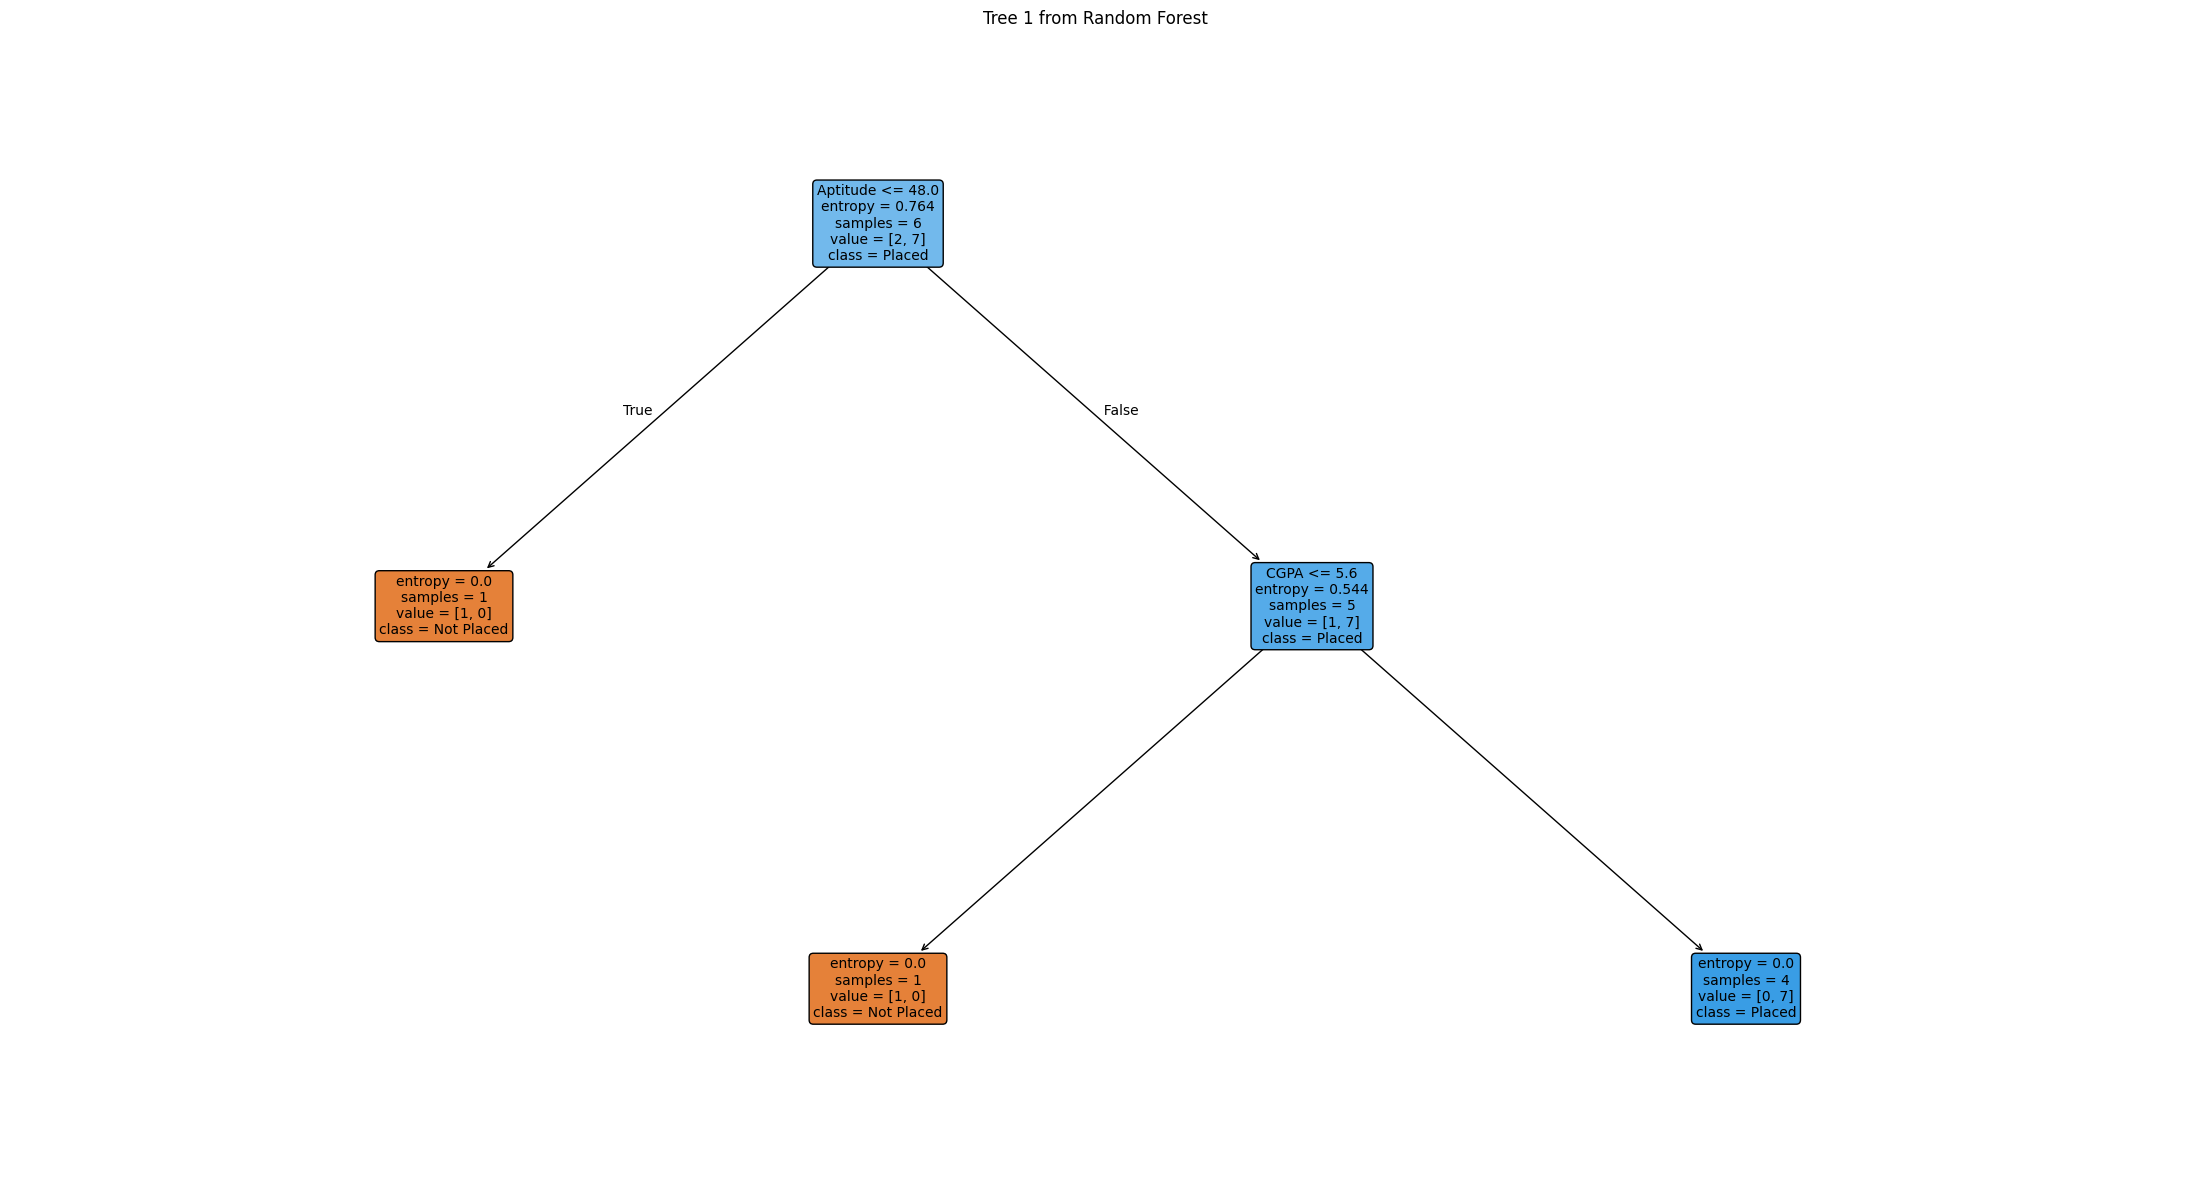

In [20]:
# ============================================================
# IMPORT plot_tree
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Tree 1 from Random Forest")
plt.tight_layout()
plt.show()


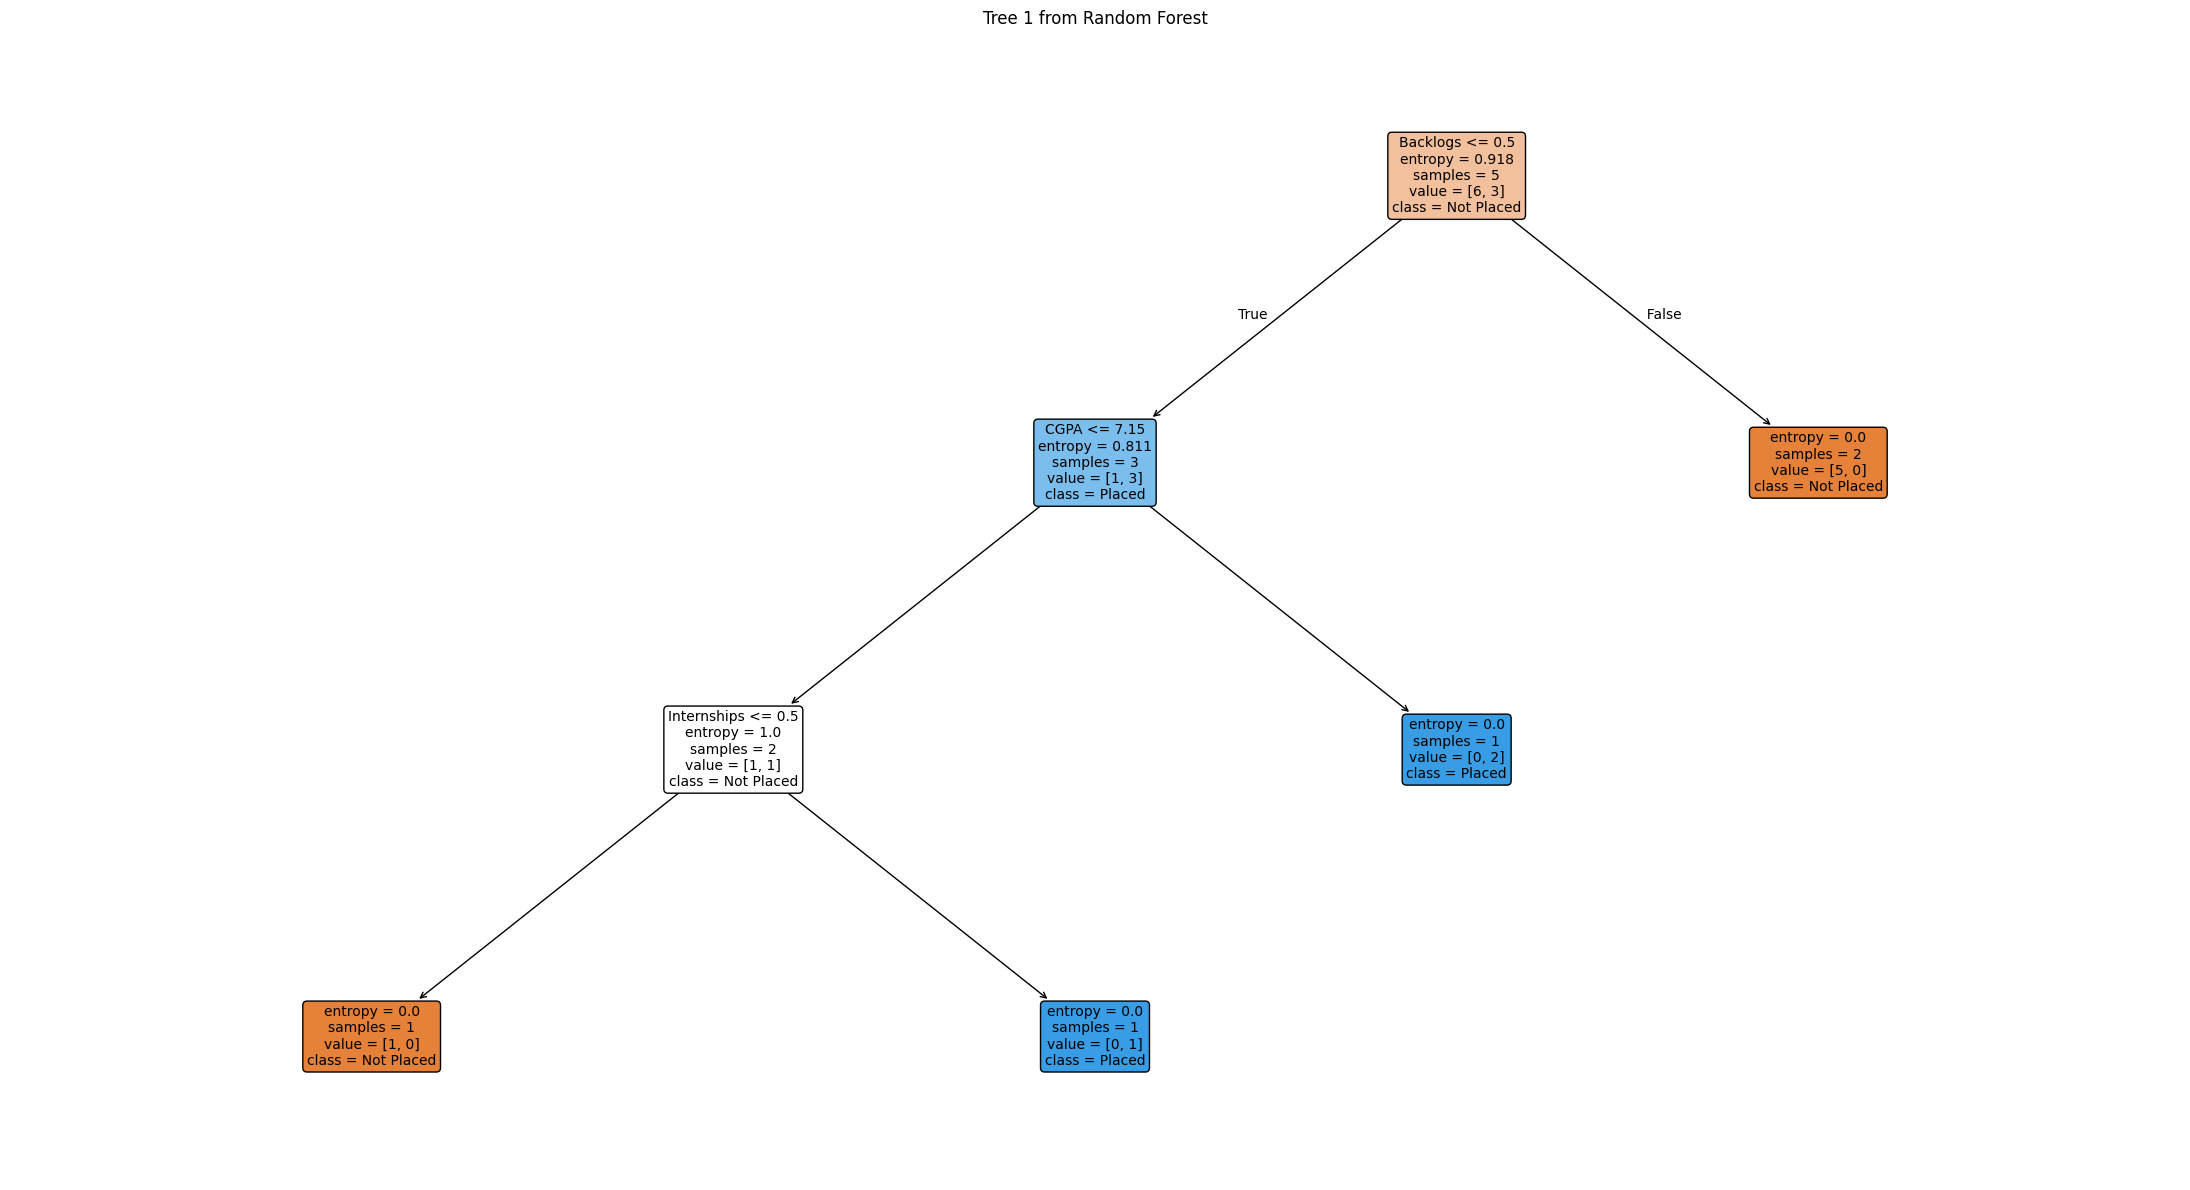

In [21]:
plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[1],
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Tree 1 from Random Forest")
plt.tight_layout()
plt.show()


In [24]:
# ============================================================
# 9. RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_val,
    rf_val_pred,
    target_names=["Not Placed", "Placed"],
    zero_division=0
))


              precision    recall  f1-score   support

  Not Placed       1.00      0.50      0.67         2
      Placed       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



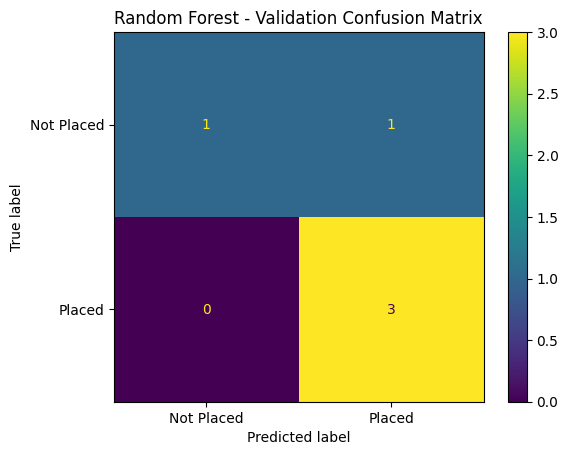

In [25]:
# ============================================================
# 10. RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_val, rf_val_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
).plot()

plt.title("Random Forest - Validation Confusion Matrix")
plt.show()



In [26]:
# ============================================================
# 11. OOB ERROR CONVERGENCE
# ============================================================

n_estimators_values = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

oob_results = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators=n,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    oob_acc = model.oob_score_

    oob_results.append({
        "n_estimators": n,
        "OOB_acc": oob_acc,
        "OOB_error": 1 - oob_acc
    })

oob_df = pd.DataFrame(oob_results)

display(oob_df.round(4))


/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,OOB_acc,OOB_error
0,1,0.4444,0.5556
1,5,0.4444,0.5556
2,10,0.5556,0.4444
3,20,0.5556,0.4444
4,30,0.5556,0.4444
5,50,0.5556,0.4444
6,75,0.5556,0.4444
7,100,0.5556,0.4444
8,150,0.5556,0.4444
9,200,0.5556,0.4444


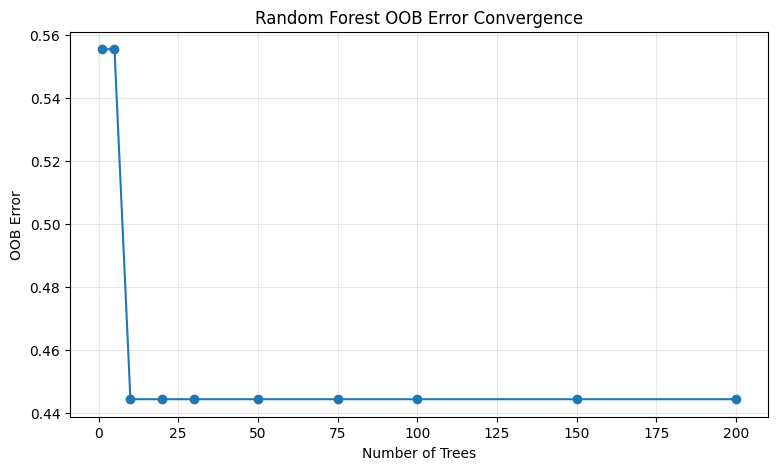

In [27]:
# ============================================================
# 12. PLOT OOB ERROR CONVERGENCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    oob_df["n_estimators"],
    oob_df["OOB_error"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error Convergence")
plt.grid(True, alpha=0.3)
plt.show()


In [28]:
# ============================================================
# 13. COMPARE max_features
# ============================================================

max_features_values = ["sqrt", "log2", None]
max_features_results = []

for mf in max_features_values:

    model = RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_features=mf,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    max_features_results.append({
        "max_features": str(mf),
        "Train_Accuracy": accuracy_score(y_train, train_pred),
        "Validation_Accuracy": accuracy_score(y_val, val_pred),
        "OOB_Accuracy": model.oob_score_,
        "OOB_Error": 1 - model.oob_score_
    })

max_features_df = pd.DataFrame(max_features_results)

display(max_features_df.round(4))


,max_features,Train_Accuracy,Validation_Accuracy,OOB_Accuracy,OOB_Error
0,sqrt,1.0,0.8,0.5556,0.4444
1,log2,1.0,0.8,0.5556,0.4444
2,None,1.0,0.6,0.5556,0.4444


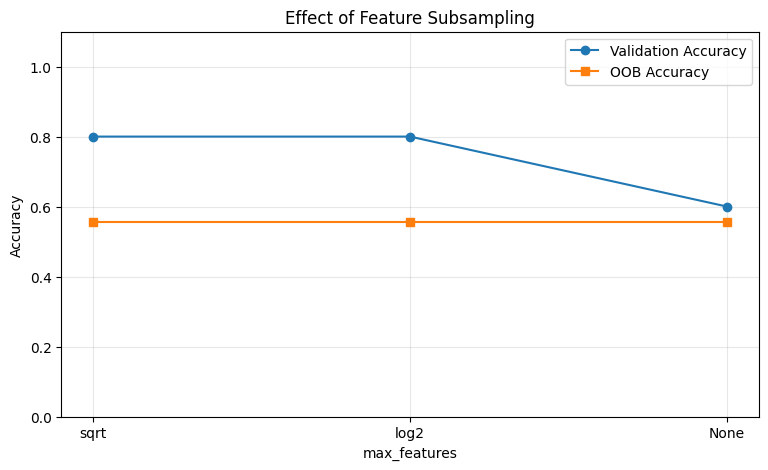

In [29]:
# ============================================================
# 14. PLOT max_features COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    max_features_df["max_features"],
    max_features_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    max_features_df["max_features"],
    max_features_df["OOB_Accuracy"],
    marker="s",
    label="OOB Accuracy"
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Subsampling")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.show()



In [30]:
# ============================================================
# 15. MANUAL BOOTSTRAP SAMPLE
# ============================================================

rng = np.random.default_rng(42)

indices = rng.choice(
    np.arange(len(X_train)),
    size=len(X_train),
    replace=True
)

oob_indices = np.setdiff1d(
    np.arange(len(X_train)),
    np.unique(indices)
)

print("Bootstrap indices:")
print(indices)

print("\nUnique selected rows:")
print(np.unique(indices))

print("\nOOB row indices:")
print(oob_indices)

print("\nTotal bootstrap observations:", len(indices))
print("Unique observations:", len(np.unique(indices)))
print("OOB observations:", len(oob_indices))


Bootstrap indices:
[0 6 5 3 3 7 0 6 1]

Unique selected rows:
[0 1 3 5 6 7]

OOB row indices:
[2 4 8]

Total bootstrap observations: 9
Unique observations: 6
OOB observations: 3


In [31]:
# ============================================================
# 16. MANUAL BAGGING: TRAIN MANY BOOTSTRAPPED TREES
# ============================================================

N_MANUAL_TREES = 50

manual_trees = []
rng = np.random.default_rng(42)

for tree_number in range(N_MANUAL_TREES):

    # Draw a bootstrap sample from training rows.
    sample_indices = rng.choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    X_boot = X_train.iloc[sample_indices]
    y_boot = y_train.iloc[sample_indices]

    tree = DecisionTreeClassifier(
        criterion="entropy",
        random_state=tree_number
    )

    tree.fit(X_boot, y_boot)
    manual_trees.append(tree)

print(f"{N_MANUAL_TREES} manually bagged trees trained.")



50 manually bagged trees trained.


In [32]:
# ============================================================
# 17. MANUAL BAGGING: MAJORITY VOTE
# ============================================================

# Each tree predicts the validation students.
tree_predictions = np.array([
    tree.predict(X_val)
    for tree in manual_trees
])

# Majority vote across all trees.
manual_bagging_pred = (
    np.mean(tree_predictions, axis=0) >= 0.5
).astype(int)

manual_bagging_acc = accuracy_score(
    y_val,
    manual_bagging_pred
)

print(
    "Manual Bootstrap Bagging Validation Accuracy:",
    f"{manual_bagging_acc:.4f}"
)



Manual Bootstrap Bagging Validation Accuracy: 0.6000


In [33]:
# ============================================================
# 18. BAGGING CLASSIFIER
# ============================================================

# Compatible with newer scikit-learn versions.
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

bagging_train_pred = bagging.predict(X_train)
bagging_val_pred = bagging.predict(X_val)

print("BAGGING PERFORMANCE")
print("=" * 50)
print(f"Training Accuracy   : {accuracy_score(y_train, bagging_train_pred):.4f}")
print(f"Validation Accuracy : {accuracy_score(y_val, bagging_val_pred):.4f}")



BAGGING PERFORMANCE
Training Accuracy   : 1.0000
Validation Accuracy : 0.6000


In [34]:
# ============================================================
# 19. PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Mean_Importance": perm.importances_mean,
    "Std_Importance": perm.importances_std
}).sort_values(
    "Mean_Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.round(4))



,Feature,Mean_Importance,Std_Importance
0,Internships,0.2200,0.1194
1,CGPA,0.1333,0.0943
2,Aptitude,0.0467,0.0846
3,Backlogs,0.0000,0.0000


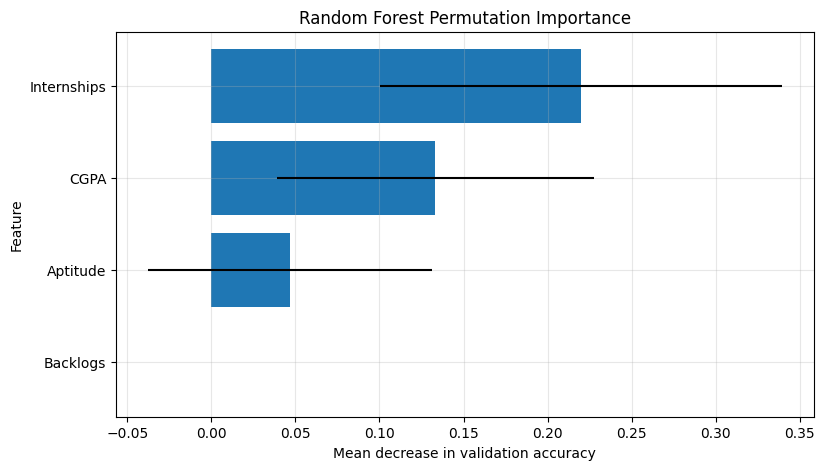

In [35]:
# ============================================================
# 20. PLOT PERMUTATION IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Mean_Importance"],
    xerr=importance_df["Std_Importance"]
)

plt.xlabel("Mean decrease in validation accuracy")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()


In [36]:
# ============================================================
# 21. rf_vs_single_tree() FUNCTION
# ============================================================

def rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
):
    """Compare Random Forest with one Decision Tree.

    Returns:
        DataFrame with columns:
        n_estimators, RF_val_acc, DT_val_acc, OOB_acc

    Also plots three lines:
        1. Random Forest validation accuracy
        2. Single Decision Tree validation accuracy
        3. Random Forest OOB accuracy
    """

    results = []

    # --------------------------------------------------------
    # Train one fixed Decision Tree baseline.
    # --------------------------------------------------------
    dt = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )

    dt.fit(X_train, y_train)

    dt_val_acc = accuracy_score(
        y_val,
        dt.predict(X_val)
    )

    # --------------------------------------------------------
    # Train Random Forests with different numbers of trees.
    # --------------------------------------------------------
    for n in n_estimators_list:

        rf_model = RandomForestClassifier(
            n_estimators=n,
            criterion="entropy",
            max_features="sqrt",
            bootstrap=True,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train, y_train)

        rf_val_acc = accuracy_score(
            y_val,
            rf_model.predict(X_val)
        )

        oob_acc = rf_model.oob_score_

        results.append({
            "n_estimators": n,
            "RF_val_acc": rf_val_acc,
            "DT_val_acc": dt_val_acc,
            "OOB_acc": oob_acc
        })

    results_df = pd.DataFrame(results)

    # --------------------------------------------------------
    # Plot the three requested lines.
    # --------------------------------------------------------
    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["n_estimators"],
        results_df["RF_val_acc"],
        marker="o",
        label="Random Forest Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["DT_val_acc"],
        marker="s",
        label="Single Decision Tree Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["OOB_acc"],
        marker="^",
        label="Random Forest OOB Accuracy"
    )

    plt.xlabel("Number of Trees (n_estimators)")
    plt.ylabel("Accuracy")
    plt.title("Random Forest vs Single Decision Tree")
    plt.legend()
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df


/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


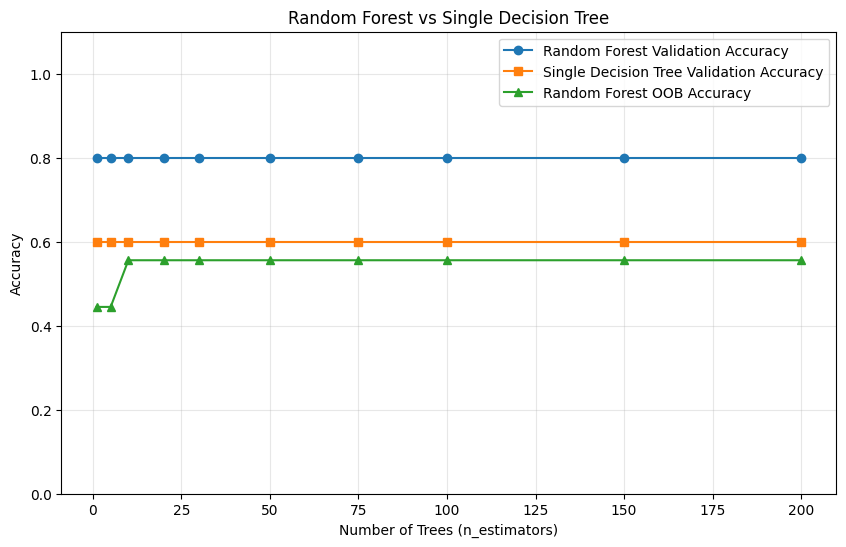

,n_estimators,RF_val_acc,DT_val_acc,OOB_acc
0,1,0.8,0.6,0.4444
1,5,0.8,0.6,0.4444
2,10,0.8,0.6,0.5556
3,20,0.8,0.6,0.5556
4,30,0.8,0.6,0.5556
5,50,0.8,0.6,0.5556
6,75,0.8,0.6,0.5556
7,100,0.8,0.6,0.5556
8,150,0.8,0.6,0.5556
9,200,0.8,0.6,0.5556


In [37]:
# ============================================================
# 22. RUN THE FUNCTION
# ============================================================

n_estimators_list = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]

rf_dt_results = rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
)

display(rf_dt_results.round(4))


In [38]:
# ============================================================
# 23. BEST RANDOM FOREST SIZE
# ============================================================

best_rf_row = rf_dt_results.loc[
    rf_dt_results["RF_val_acc"].idxmax()
]

print("Best Random Forest result based on validation accuracy:")
print("=" * 65)
print(best_rf_row.to_string())


Best Random Forest result based on validation accuracy:
n_estimators    1.000000
RF_val_acc      0.800000
DT_val_acc      0.600000
OOB_acc         0.444444
